In [1]:
import numpy as np
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Image, display, HTML

# Параметры
num_states = 8*8 * 8*8 # Количество состояний
num_actions = 4  # Количество действий

In [2]:
# Функция для получения индекса состояния в Q-таблице
def get_index(state: List[int]) -> int:
    return 64 * (state[0] + 8 * state[1]) + state[2] + 8 * state[3]

# Функция для получения координат цели и агента из индекса состояния
def get_state(ind: int) -> List[int]:
    x_a = ind // 64 % 8
    y_a = ind // 64 // 8
    x_t = ind % 64 % 8
    y_t = ind % 64 // 8
    return [x_a, y_a, x_t, y_t]

# Расчет манхэттенского расстояния
def get_distance(a_coord: List[int], t_coord: List[int]) -> int:
    return abs(a_coord[0] - t_coord[0]) + abs(a_coord[1] - t_coord[1])

In [3]:
def q_learning(episodes:int, epsilon:float, alpha:float):
    Q = np.zeros((num_states, num_actions))  # Q-таблица для состояний и действий
    info = [[], [], []]
    states = []

    for i in range(episodes):
        index = np.random.randint(num_states)  # Случайное начальное состояние
        state = get_state(index) # Координаты цели и агента
        n_steps = 0

        # Запись данных по итерации обучения
        info[0].append(i)
        info[1].append(get_distance(state[0:2], state[2:4]))

        # Запись изначального состояния итерации для отображения
        states.append(state)

        while state[0:2] != state[2:4]:  # Цикл до достижения агентом цели
            # Определение текущего расстояния до цели
            distance = get_distance(state[0:2], state[2:4])
            
            # Выбор действия
            if np.random.rand() < epsilon:
                action = np.random.randint(num_actions)  # Исследование
            else:
                action = np.argmax(Q[index])  # Эксплуатация
            
            # Определение нового состояния
            if action == 0:
                if state[1] + 1 > 7: continue
                else: state[1] += 1
            elif action == 1:
                if state[0] + 1 > 7: continue
                else: state[0] += 1
            elif action == 2:
                if state[1] - 1 < 0: continue
                else: state[1] -= 1
            elif action == 3:
                if state[0] - 1 < 0: continue
                else: state[0] -= 1

            # Определение награды
            reward = (distance - get_distance(state[0:2], state[2:4])) / distance
            
            # Обновление Q-значения
            Q[index, action] += alpha * (reward + np.max(Q[get_index(state)]) - Q[index, action])
            
            # Переход к следующему состоянию
            index = get_index(state)

            # Подсчет шагов
            n_steps += 1

            # Запись состояний для отображения
            states.append(state.copy())
        
        info[2].append(n_steps)
    
    df = pd.DataFrame({
        'id': info[0],
        'distance': info[1],
        'steps': info[2]
    })
    df['steps/distance'] = df['steps'] / df['distance']

    return df, states

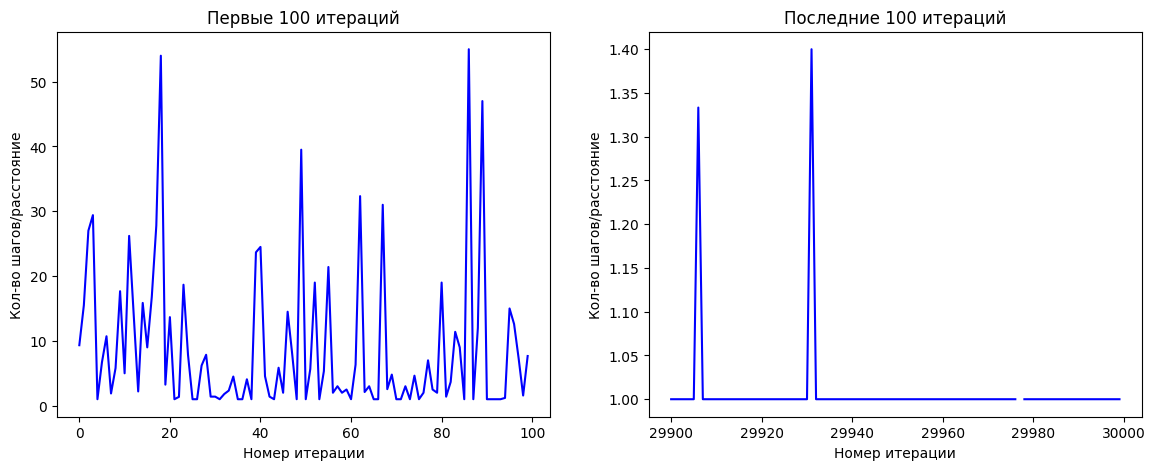

In [4]:
# Обучение
df, states = q_learning(30000, 0.01, 0.1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 строка, 2 столбца

# Создание первого графика
axs[0].plot(df['id'].head(100), df['steps/distance'].head(100), 'b-')
axs[0].set_title('Первые 100 итераций')
axs[0].set_xlabel('Номер итерации')
axs[0].set_ylabel('Кол-во шагов/расстояние')

# Создание второго графика
axs[1].plot(df['id'].tail(100), df['steps/distance'].tail(100), 'b-')
axs[1].set_title('Последние 100 итераций')
axs[1].set_xlabel('Номер итерации')
axs[1].set_ylabel('Кол-во шагов/расстояние')

# Показать графики
plt.show()

In [5]:
# Инициализация графика
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.set_xticks(range(9))
ax.set_yticks(range(9))
ax.grid(True)

# Создаем точки для агента и цели
agent_dot, = ax.plot([], [], 'bo', label='Агент')
target_dot, = ax.plot([], [], 'ro', label='Цель')

# Настройка легенды
ax.legend()

# Функция инициализации
def init():
    agent_dot.set_data([], [])
    target_dot.set_data([], [])
    return agent_dot, target_dot

# Функция обновления для анимации
def update(frame):
    x_agent, y_agent, x_target, y_target = states[:1000][frame]
    
    agent_dot.set_data(x_agent, y_agent)
    target_dot.set_data(x_target, y_target)
    
    return agent_dot, target_dot

# Создание анимации
ani = FuncAnimation(fig, update, frames=len(states[:1000]), init_func=init, blit=True, repeat=False)

# Сохранение анимации в формате GIF с использованием Pillow
ani.save('first_1000_steps.gif', writer='pillow', fps=4)
plt.close(fig)

In [6]:
# Инициализация графика
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.set_xticks(range(9))
ax.set_yticks(range(9))
ax.grid(True)

# Создаем точки для агента и цели
agent_dot, = ax.plot([], [], 'bo', label='Агент')
target_dot, = ax.plot([], [], 'ro', label='Цель')

# Настройка легенды
ax.legend()

# Функция инициализации
def init():
    agent_dot.set_data([], [])
    target_dot.set_data([], [])
    return agent_dot, target_dot

# Функция обновления для анимации
def update(frame):
    x_agent, y_agent, x_target, y_target = states[-1000:][frame]
    
    agent_dot.set_data(x_agent, y_agent)
    target_dot.set_data(x_target, y_target)
    
    return agent_dot, target_dot

# Создание анимации
ani = FuncAnimation(fig, update, frames=len(states[-1000:]), init_func=init, blit=True, repeat=False)

# Сохранение анимации в формате GIF с использованием Pillow
ani.save('last_1000_steps.gif', writer='pillow', fps=4)
plt.close(fig)

In [7]:
# Создание HTML-кода для отображения GIF
html_code = f"""
<div style="display: flex; justify-content: space-around; align-items: center;">
    <div style="text-align: center;">
        <h3>Первые 1000 шагов агента</h3>
        <img src="first_1000_steps.gif" alt="GIF 1" style="width: 700px; height: auto;"/>
    </div>
    <div style="text-align: center;">
        <h3>Последние 1000 шагов агента</h3>
        <img src="last_1000_steps.gif" alt="GIF 2" style="width: 700px; height: auto;"/>
    </div>
</div>
"""

# Отображение
display(HTML(html_code))